# GPU Example: Ice Lines

**This is the GPU-enabled version of the standard DustPy ice-line example. The simulation uses the CuPy backend, while plotting data is transferred to NumPy only at the plotting boundary.**

Ice lines are locations in protoplanetary disks where the temperature drops below a value where a chemical species can freeze out.

It has long been speculated that different chemical compositions of dust particles can influence their collisional behavior depending on the different surface forces these species have. This can to first order be implemented by changing the fragmentation velocity depending on the temperature in the disk.

The example here is similar to [Pinilla et al. (2017)](https://doi.org/10.3847/1538-4357/aa7edb):

Above $150\,\mathrm{K}$ all volatiles are evaporated and only the bare silicate grains are left. We use a fragmentation velocity of $1\,\mathrm{m/s}$. Below $150\,\mathrm{K}$ water freezes out onto the grains, and we use $10\,\mathrm{m/s}$. At about $80\,\mathrm{K}$ ammonia $\left(\mathrm{NH}_3\right)$ freezes out, and we use $7\,\mathrm{m/s}$. At $44\,\mathrm{K}$ carbon dioxide $\left(\mathrm{CO}_2\right)$ freezes out, and the fragmentation velocity returns to $1\,\mathrm{m/s}$.

However, [Musiolik & Wurm (2019)](https://doi.org/10.3847/1538-4357/ab0428) suggest that these differences might not exist. We use them here for demonstration purposes. The same method can also implement sintering effects as described by [Okuzumi et al. (2016)](https://doi.org/10.3847/0004-637X/821/2/82).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import dustpy.constants as c
from dustpy import Simulation
from dustpy.utils import to_numpy  # Transfer backend arrays to NumPy at plotting boundaries
from simframe.backends.api import xp  # Backend-neutral array API; mapped to CuPy for this simulation

In [2]:
sim = Simulation(backend="cupy")  # N.B.: use the CuPy backend for GPU acceleration

In [3]:
sim.initialize()
sim.t.snapshots = np.append(sim.t.snapshots[sim.t.snapshots < 1.e5*c.year], 1.e5*c.year)

At this point the fragmentation velocity is constant with the default value of $1\,\mathrm{m/s}$. **Matplotlib expects host arrays, so custom plotting code transfers only the plotted fields with `to_numpy`.**

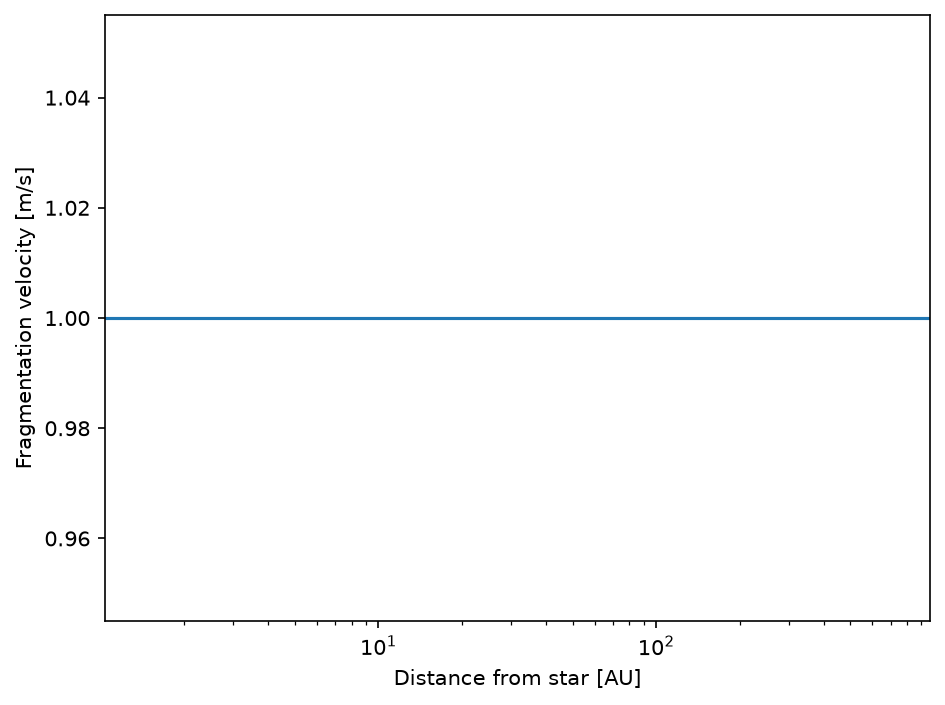

In [4]:
r_au = to_numpy(sim.grid.r) / c.au
v_frag = to_numpy(sim.dust.v.frag) / 100.

fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.semilogx(r_au, v_frag)
ax.set_xlim(r_au[0], r_au[-1])
ax.set_xlabel("Distance from star [AU]")
ax.set_ylabel("Fragmentation velocity [m/s]")
fig.tight_layout()
plt.show()

We now write a backend-neutral function that constructs the fragmentation velocity according to the prescription above. 

**The `xp` API maps these operations to NumPy or CuPy according to the active simulation backend.**

In [5]:
def vfrag(sim):
    vfrag = xp.where(sim.gas.T < 150., 1000., 100.)
    vfrag = xp.where(sim.gas.T < 80., 700., vfrag)
    vfrag = xp.where(sim.gas.T < 44., 100., vfrag)
    return vfrag

We can assign the return value of this function to the fragmentation velocity. **With the CuPy backend, `vfrag` returns a CuPy array, so this assignment keeps the field on the GPU.**

In [6]:
sim.dust.v.frag = vfrag(sim)

We also update the whole simulation frame to update the fields that depend on the fragmentation velocity.

In [7]:
sim.update()

The fragmentation velocity now changes at the introduced ice lines.

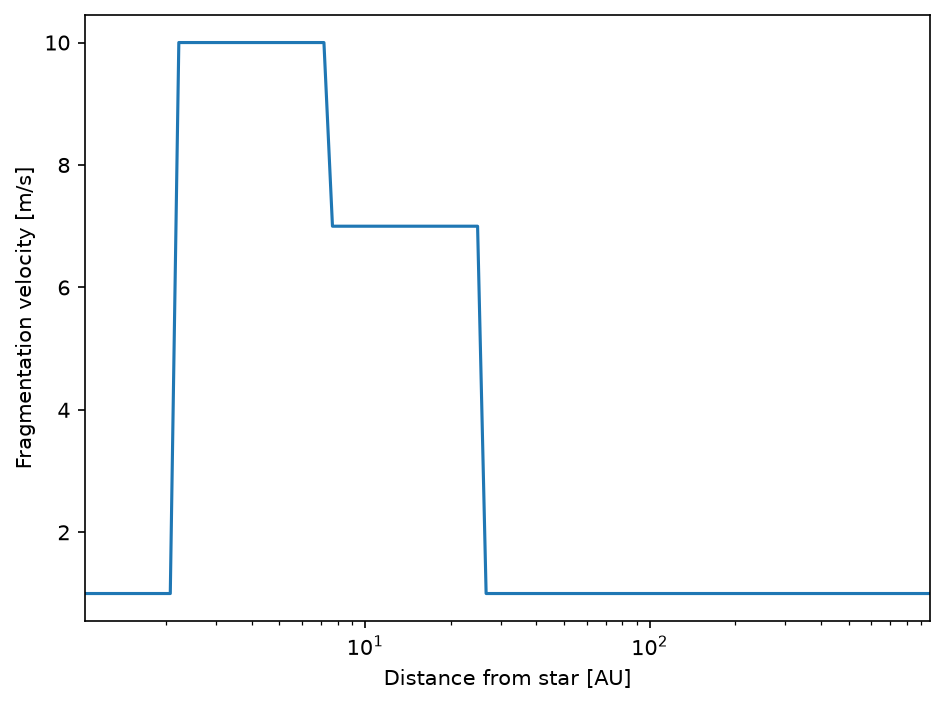

In [8]:
r_au = to_numpy(sim.grid.r) / c.au
v_frag = to_numpy(sim.dust.v.frag) / 100.

fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.semilogx(r_au, v_frag)
ax.set_xlim(r_au[0], r_au[-1])
ax.set_xlabel("Distance from star [AU]")
ax.set_ylabel("Fragmentation velocity [m/s]")
fig.tight_layout()
plt.show()

We do not assign our function to the updater of the fragmentation velocities. Since the temperature profile is constant in the default model, the fragmentation velocity does not change and does not need to be updated at every time step.

We are now ready to start the simulation.

In [9]:
sim.writer.datadir = "data/gpu_example_ice_lines"

In [10]:
sim.run()


DustPy-GPU v1.0.9.2 (based on DustPy v1.0.9)
Backend: cupy

Documentation (DustPy): https://stammler.github.io/dustpy/
PyPI (DustPy): https://pypi.org/project/dustpy/
GitHub (DustPy): https://github.com/stammler/dustpy/
GitHub (DustPy-GPU): https://github.com/astroboylrx/dustpy-gpu/
GPU examples: https://github.com/astroboylrx/dustpy-gpu/tree/master/gpu_examples

Please cite Stammler & Birnstiel (2022) for DustPy
and Li & Chiang (2026) for DustPy-GPU.

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.82e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  4.44e-16
        for particle collision
            m[32] =  3.73e-08 g    with
            m[38] =  2.68e-07 g
    - Erosion:
        max. rel. error:  1.78e-15
        for particle collision
            m[110] =  5.18e+03 g    with
            m[118] =  7.20e+04 g

Creating data directory data/gp

Writing dump file data/gpu_example_ice_lines/frame.dmp


Writing file data/gpu_example_ice_lines/data0001.hdf5


Writing dump file data/gpu_example_ice_lines/frame.dmp


Writing file data/gpu_example_ice_lines/data0002.hdf5


...

Writing dump file data/gpu_example_ice_lines/frame.dmp


Writing file data/gpu_example_ice_lines/data0020.hdf5


Writing dump file data/gpu_example_ice_lines/frame.dmp


Writing file data/gpu_example_ice_lines/data0021.hdf5


Writing dump file data/gpu_example_ice_lines/frame.dmp
Execution time: 0:16:08


Here is the result of our simulation. 

**`plot.panel` accepts a CuPy-backed `Simulation` directly and performs the required device-to-host transfer internally.**

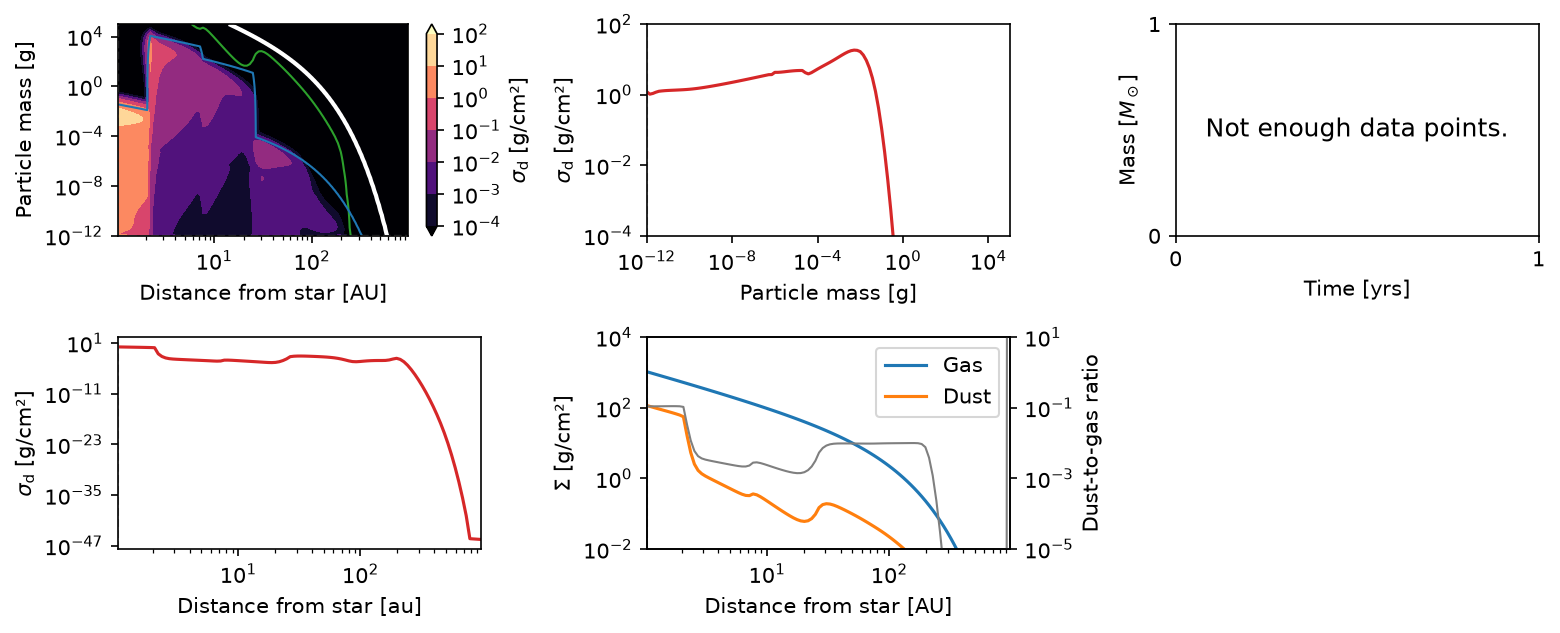

In [11]:
from dustpy import plot

plot.panel(sim)

The inner disk is enriched in dust because of the so-called traffic-jam effect. Dust particles outside the water ice line grow to larger sizes and drift rapidly. After crossing the water ice line, they fragment down to slowly drifting particles, so dust accumulates inside the water ice line.